## E1

In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

### 1. Descargar red vial de Macul

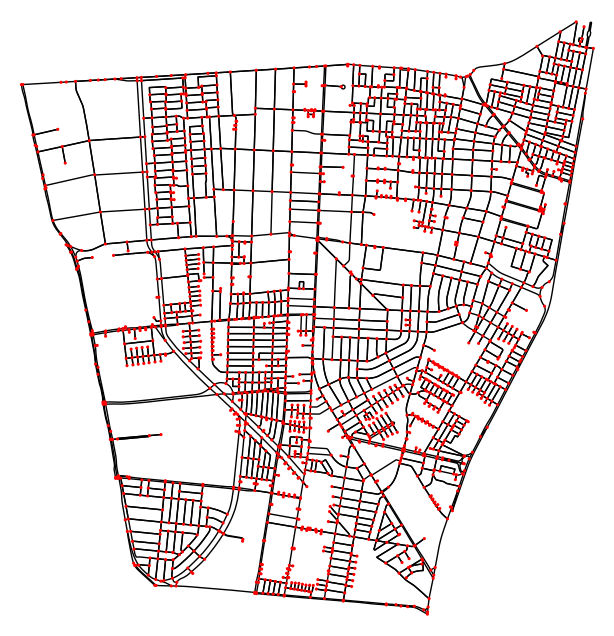

In [2]:
place_name = "Macul, Santiago, Chile"

G = ox.graph_from_place(
    place_name,
    network_type="drive",
    simplify=True
)

ox.plot_graph(
    G,
    figsize=(8, 8),
    node_size=5,
    bgcolor="white",
    edge_color="black",
    node_color="red"
);

###  2. Definir puntos extremos

Google Maps entrega: latitud, longitud
OSMnx nearest_nodes pide: longitud, latitud

In [3]:
punto_ne = {
    "nombre": "Extremo nororiente aproximado",
    "lat": -33.4730,
    "lon": -70.5790
}

punto_sw = {
    "nombre": "Extremo surponiente aproximado",
    "lat": -33.5105,
    "lon": -70.6215
}

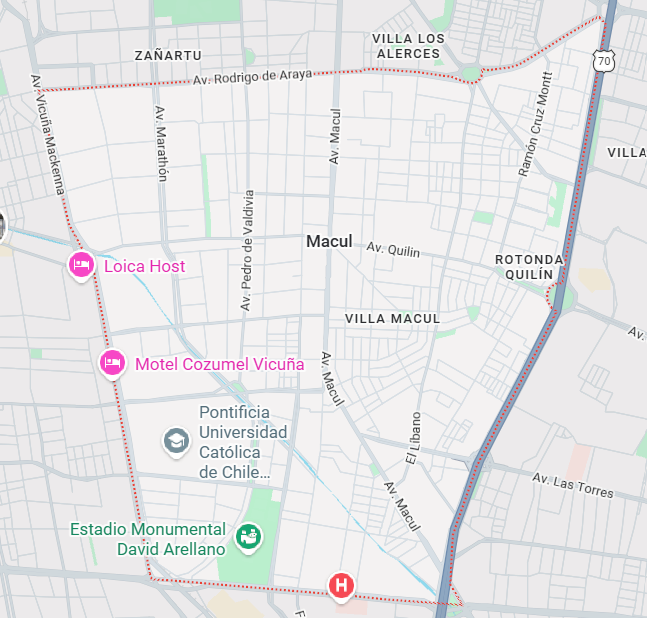

In [4]:
from PIL import Image
Image.open("macul_google.png")


In [5]:
nodo_ne = ox.distance.nearest_nodes(
    G,
    X=punto_ne["lon"],
    Y=punto_ne["lat"]
)

nodo_sw = ox.distance.nearest_nodes(
    G,
    X=punto_sw["lon"],
    Y=punto_sw["lat"]
)

print(f"Nodo nororiente: {nodo_ne}")
print(f"Nodo surponiente: {nodo_sw}")

Nodo nororiente: 434262553
Nodo surponiente: 5703399254


### 3. Leer shapefile y encontrar Macul

In [6]:
ruta_comunas = "datos_geoespaciales/Comunas/comunas.shp"

comunas = gpd.read_file(ruta_comunas)

print(f"CRS original comunas: {comunas.crs}")
print(f"CRS red OSMnx: {G.graph['crs']}")

CRS original comunas: EPSG:3857
CRS red OSMnx: epsg:4326


epsg:4326 es el sistema de coordenadas geográficas (latitud, longitud)

epsg:3857 es el sistema de coordenadas proyectadas (metros aproximados)

epsg:32719 es el sistema de coordenadas proyectadas específico para Chile (metros exactos)

In [7]:
macul = comunas[
    comunas["Comuna"] == "Macul"
].copy()

macul

,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
31,319,15200.750374,10,7,13118,13,1.844788e+07,18197.177631,Región Metropolitana de Santiago,Macul,Santiago,"POLYGON ((-7856575.614 -3957891.521, -7856687...."


In [8]:
G.graph["crs"]

'epsg:4326'

In [9]:
macul_metrico = macul.to_crs(32719)

### 4. Centroide

a) Opcion basica: obtenga las coordenadas aproximadas desde un servicio web de mapas.

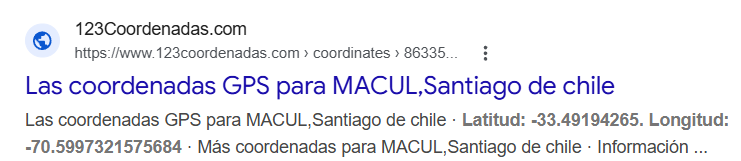

In [10]:
Image.open("centroide_macul_web.png")

In [11]:
centroide_opcion_a = (-33.4919, -70.5997)  # latitud, longitud

In [12]:
nodo_opcion_a = ox.distance.nearest_nodes(
    G,
    X=centroide_opcion_a[1],  # longitud
    Y=centroide_opcion_a[0]   # latitud
)
print(f"Nodo más cercano a la opción A: {nodo_opcion_a}")

Nodo más cercano a la opción A: 2519246353


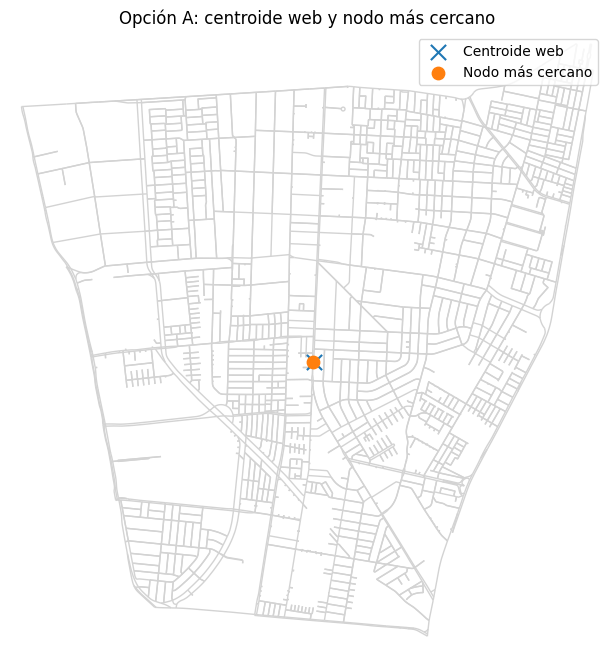

In [13]:
lat_a, lon_a = centroide_opcion_a

lon_nodo_a = G.nodes[nodo_opcion_a]["x"]
lat_nodo_a = G.nodes[nodo_opcion_a]["y"]

fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color="lightgray",
    bgcolor="white",
    show=False,
    close=False,
    figsize=(8, 8)
)

ax.scatter(lon_a, lat_a, s=120, marker="x", label="Centroide web")
ax.scatter(lon_nodo_a, lat_nodo_a, s=80, marker="o", label="Nodo más cercano")

ax.legend()
ax.set_title("Opción A: centroide web y nodo más cercano")
plt.show()

Otra opción para mirar

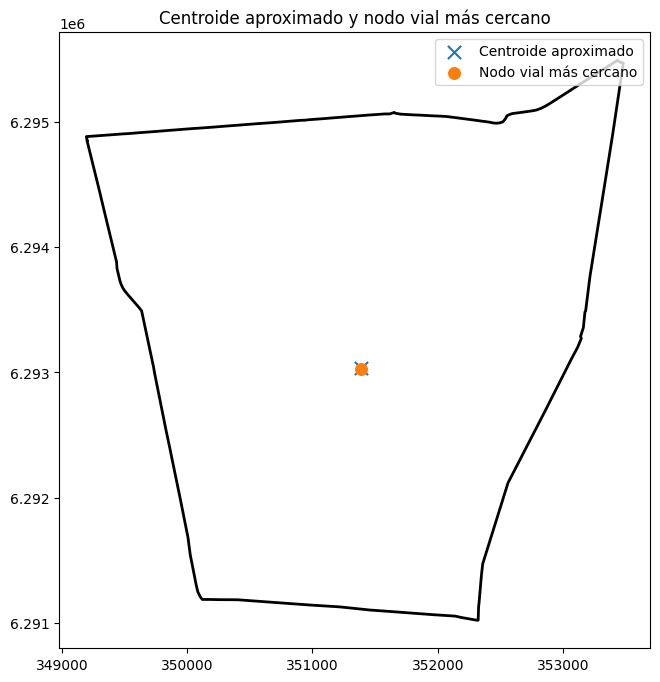

In [14]:
from shapely.geometry import Point

lat_a, lon_a = centroide_opcion_a

lon_nodo_a = G.nodes[nodo_opcion_a]["x"]
lat_nodo_a = G.nodes[nodo_opcion_a]["y"]

# creamos puntos en lat lon y convertir a GeoSeries
punto_web = gpd.GeoSeries(
    [Point(lon_a, lat_a)],
    crs="EPSG:4326"
).to_crs(epsg=32719)

punto_nodo = gpd.GeoSeries(
    [Point(lon_nodo_a, lat_nodo_a)],
    crs="EPSG:4326"
).to_crs(epsg=32719)

fig, ax = plt.subplots(figsize=(8, 8))

macul_metrico.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2
)

punto_web.plot(
    ax=ax,
    markersize=90,
    marker="x",
    label="Centroide aproximado"
)

punto_nodo.plot(
    ax=ax,
    markersize=70,
    marker="o",
    label="Nodo vial más cercano"
)

plt.title("Centroide aproximado y nodo vial más cercano")
plt.legend()
plt.show()

b) Opcion media: obtenga el centroide del distrito censal m´as central de la comuna.

In [15]:
ruta_distritos = "datos_geoespaciales/Distritos Censales/Distritos Censales RM.shp"

distritos = gpd.read_file(ruta_distritos)

print("CRS distritos:", distritos.crs)
distritos.head()

CRS distritos: EPSG:32719


,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6..."
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,"POLYGON ((345880.28 6299633.958, 345961.61 629..."
2,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,1310103.0,38.0,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,"POLYGON ((345546.017 6299748.84, 345650.511 62..."
3,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,1310104.0,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,"POLYGON ((344856.32 6298892.632, 345672.277 62..."
4,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,1310105.0,45.0,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,"POLYGON ((343856.526 6298225.435, 344041.982 6..."


In [16]:
distritos = distritos.to_crs(macul.crs)

nos quedamos con los distritos que intersectan con Macul

In [17]:
distritos_macul = gpd.sjoin(
    distritos,
    macul[["Comuna", "geometry"]],
    how="inner",
    predicate="intersects"
)

display(distritos_macul.head())
print(f"Cantidad de distritos en/intersectando Macul: {len(distritos_macul)}")

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry,index_right,Comuna
173,Región Metropolitana De Santiago,131,Santiago,13118,Macul,Lo Plaza,1311801.0,187.0,1310.0,1643.0,936.0,172.0,4248.0,1304277.83,32.57,7.85,"POLYGON ((-7859075.915 -3958386.291, -7858901....",31,Macul
174,Región Metropolitana De Santiago,131,Santiago,13118,Macul,Macul,1311802.0,185.0,1652.0,2338.0,2185.0,560.0,6920.0,2560931.73,27.02,8.14,"POLYGON ((-7859137.174 -3959889.54, -7858970.2...",31,Macul
175,Región Metropolitana De Santiago,131,Santiago,13118,Macul,Pedreros,1311803.0,159.0,1478.0,2229.0,2042.0,496.0,6404.0,2944739.99,21.75,6.69,"POLYGON ((-7861046.382 -3961366.919, -7860973....",31,Macul
176,Región Metropolitana De Santiago,131,Santiago,13118,Macul,Camino Agrícola,1311804.0,109.0,1279.0,1863.0,1320.0,308.0,4879.0,1941906.73,25.12,9.15,"POLYGON ((-7861378.164 -3960004.725, -7861238....",31,Macul
177,Región Metropolitana De Santiago,131,Santiago,13118,Macul,Villa Santa Carolina,1311805.0,31.0,445.0,1002.0,1158.0,247.0,2883.0,2507307.39,11.50,9.58,"POLYGON ((-7859917.494 -3958436.682, -7859497....",31,Macul


Cantidad de distritos en/intersectando Macul: 13


Usamos intersects porque a veces los límites no calzan perfecto. Si usamos within, podemos perder distritos que tocan el borde o tienen pequeñas diferencias geométricas.

Ahora calcular el distrito censal más central

In [18]:
macul_metrico = macul.to_crs(epsg=32719) # ya lo teníamos definido, pero igual
distritos_macul_metrico = distritos_macul.to_crs(epsg=32719)

In [19]:
distritos_macul_metrico.plot(
    ax=ax,
    column="NOM_DIS",
    cmap="Set3",
    edgecolor="gray",
    linewidth=0.8,
    legend=True
)

<Axes: title={'center': 'Centroide aproximado y nodo vial más cercano'}>

In [20]:
centroide_macul = macul_metrico.geometry.iloc[0].centroid # centroide pero referencial

In [21]:
distritos_macul_metrico["centroide_distrito"] = (
    distritos_macul_metrico.geometry.centroid
)

In [22]:
distritos_macul_metrico["distancia_al_centro"] = (
    distritos_macul_metrico["centroide_distrito"]
    .distance(centroide_macul)
)

In [23]:
idx_mas_central = distritos_macul_metrico["distancia_al_centro"].idxmin()

distrito_central = distritos_macul_metrico.loc[[idx_mas_central]].copy()

distrito_central

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,...,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry,index_right,Comuna,centroide_distrito,distancia_al_centro
176,Región Metropolitana De Santiago,131,Santiago,13118,Macul,Camino Agrícola,1311804.0,109.0,1279.0,1863.0,...,308.0,4879.0,1941906.73,25.12,9.15,"POLYGON ((349497.308 6293647.832, 349614.292 6...",31,Macul,POINT (350519.158 6293180.502),849.302128


In [24]:
centroide_distrito_metrico = distrito_central["centroide_distrito"].iloc[0]

centroide_opcion_b = (
    gpd.GeoSeries([centroide_distrito_metrico], crs="EPSG:32719")
    .to_crs(G.graph["crs"])
)

lon_centro = centroide_opcion_b.x.iloc[0]
lat_centro = centroide_opcion_b.y.iloc[0]

print("Centroide del distrito censal más central:")
print(f"Latitud: {lat_centro}")
print(f"Longitud: {lon_centro}")

Centroide del distrito censal más central:
Latitud: -33.49045630189981
Longitud: -70.60904446268455


In [25]:
nodo_centro_b = ox.distance.nearest_nodes(
    G,
    X=lon_centro,  # longitud
    Y=lat_centro   # latitud
)

print(f"Nodo más cercano al centroide del distrito central: {nodo_centro_b}")

Nodo más cercano al centroide del distrito central: 276279433


C:\Users\jjacq\AppData\Local\Temp\ipykernel_9532\3425497043.py:43: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


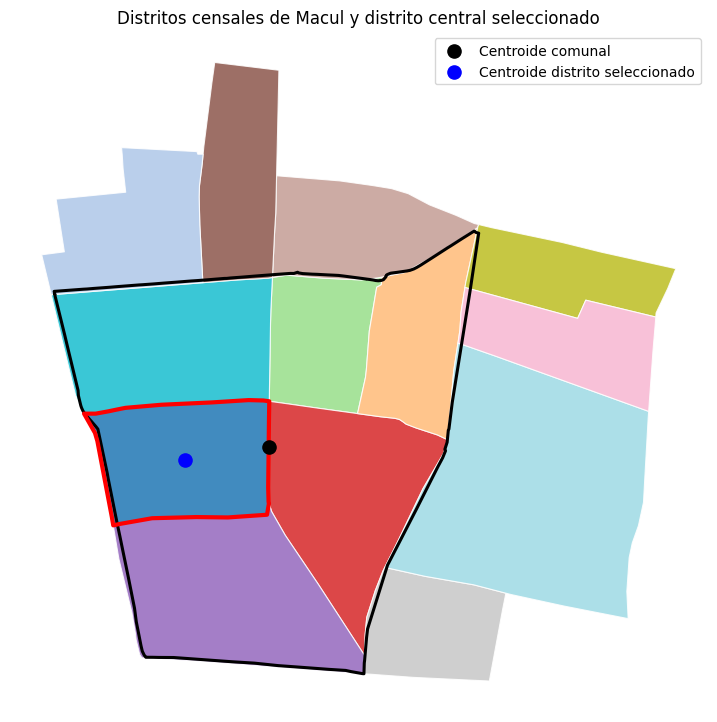

In [26]:
fig, ax = plt.subplots(figsize=(9, 9))

distritos_macul_metrico.plot(
    ax=ax,
    column="NOM_DIS", 
    cmap="tab20",
    edgecolor="white",
    linewidth=0.8,
    legend=True,
    alpha=0.85
)

macul_metrico.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2.2
)

distrito_central.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=3,
    label="Distrito seleccionado"
)

gpd.GeoSeries([centroide_macul], crs="EPSG:32719").plot(
    ax=ax,
    markersize=90,
    color="black",
    label="Centroide comunal"
)

gpd.GeoSeries([centroide_distrito_metrico], crs="EPSG:32719").plot(
    ax=ax,
    markersize=90,
    color="blue",
    label="Centroide distrito seleccionado"
)

plt.title("Distritos censales de Macul y distrito central seleccionado")
plt.legend()
plt.axis("off")
plt.show()

Ahora lo mismo, pero con Open Street

C:\Users\jjacq\AppData\Local\Temp\ipykernel_9532\340277573.py:71: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


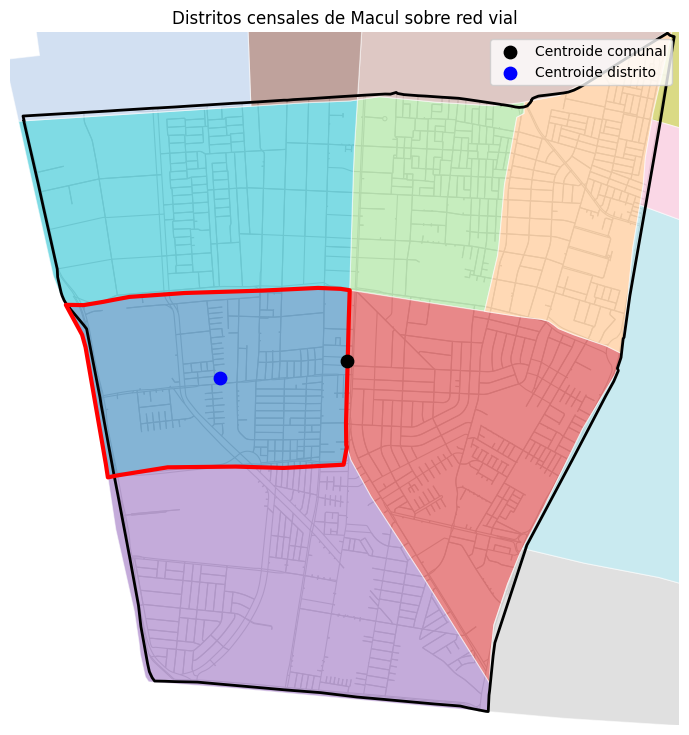

In [27]:
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color="lightgray",
    edge_linewidth=0.8,
    bgcolor="white",
    figsize=(9, 9),
    show=False,
    close=False
)

# pasar capas distritales al CRS de OSMnx
distritos_macul_wgs84 = distritos_macul_metrico.to_crs(G.graph["crs"])
distrito_central_wgs84 = distrito_central.to_crs(G.graph["crs"])
macul_wgs84 = macul_metrico.to_crs(G.graph["crs"])

centroide_macul_wgs84 = (
    gpd.GeoSeries([centroide_macul], crs="EPSG:32719")
    .to_crs(G.graph["crs"])
)

centroide_distrito_wgs84 = (
    gpd.GeoSeries([centroide_distrito_metrico], crs="EPSG:32719")
    .to_crs(G.graph["crs"])
)

# colorear distritos
distritos_macul_wgs84.plot(
    ax=ax,
    column="NOM_DIS", 
    cmap="tab20",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.55,
    legend=True
)

# limite comunal
macul_wgs84.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2
)

# distrito seleccionado
distrito_central_wgs84.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=3,
    label="Distrito seleccionado"
)

# centroides
centroide_macul_wgs84.plot(
    ax=ax,
    markersize=80,
    color="black",
    label="Centroide comunal"
)

centroide_distrito_wgs84.plot(
    ax=ax,
    markersize=80,
    color="blue",
    label="Centroide distrito"
)

ax.set_title("Distritos censales de Macul sobre red vial")
ax.legend()
plt.show()

c) Opcion avanzada: utilice la funcion dissolve sobre los distritos censales para obtener los limites
geograficos de las comunas y, a partir de estos, el centroide correspondiente

In [28]:
print("CRS distritos:", distritos.crs)
print("Columnas:", distritos.columns)

# construir limites comunales uniendo distritos por comuna
comunas_desde_distritos = distritos.dissolve(by="NOM_COM").reset_index()

# filtrar Macul
macul_dissolve = comunas_desde_distritos[
    comunas_desde_distritos["NOM_COM"] == "Macul"
].copy()

macul_dissolve

CRS distritos: EPSG:3857
Columnas: Index(['NOM_REG', 'COD_PROV', 'NOM_PROV', 'COD_COM', 'NOM_COM', 'NOM_DIS',
       'CODIGO', 'E', 'D', 'C3', 'C2', 'ABC1', 'ADIMARK_T', 'Area', 'Densidad',
       '1_UF_M2', 'geometry'],
      dtype='object')


,NOM_COM,geometry,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_DIS,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2
24,Macul,"POLYGON ((-7858082.362 -3963212.746, -7858523....",Región Metropolitana De Santiago,131,Santiago,13118,Lo Plaza,1311801.0,187.0,1310.0,1643.0,936.0,172.0,4248.0,1304277.83,32.57,7.85


In [29]:
# CRS metrico local para calcular centroide
macul_metrico = macul_dissolve.to_crs(epsg=32719)

centroide_metrico = macul_metrico.geometry.iloc[0].centroid

In [30]:
G.graph["crs"]

'epsg:4326'

In [31]:

centroide_opcion_c = (
    gpd.GeoSeries([centroide_metrico], crs=macul_metrico.crs)
    .to_crs(G.graph["crs"])
)

lon_centro = centroide_opcion_c.x.iloc[0]
lat_centro = centroide_opcion_c.y.iloc[0]

print("Centroide de Macul obtenido con dissolve:")
print(f"Latitud: {lat_centro}")
print(f"Longitud: {lon_centro}")

Centroide de Macul obtenido con dissolve:
Latitud: -33.48962137496448
Longitud: -70.60031584175445


In [ ]:
nodo_centro_c = ox.distance.nearest_nodes(
    G,
    X=lon_centro,
    Y=lat_centro
)

Nodo más cercano al centroide: 515234974


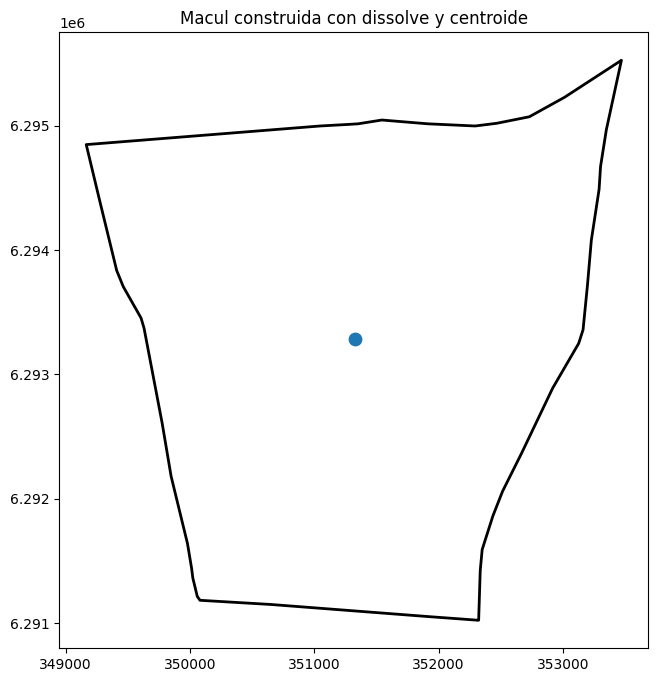

In [33]:
print(f"Nodo más cercano al centroide: {nodo_centro_c}")

fig, ax = plt.subplots(figsize=(8, 8))

macul_metrico.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2
)

gpd.GeoSeries([centroide_metrico], crs=macul_metrico.crs).plot(
    ax=ax,
    markersize=80
)

plt.title("Macul construida con dissolve y centroide")
plt.show()

###  7. Calcule las rutas  optimas entre los puntos extremos y el centroide

Dado que tengo los 3 casos, es mejor hacer la función y así reutilizarla para cada punto extremo. 
La función va a recibir el grafo, el nodo de origen y el nodo del centroide, y va a devolver la ruta óptima entre ambos.

In [34]:
def ruta_pasando_por_centroide(
    G,
    nodo_origen,
    nodo_destino,
    nodo_centroide,
    usar_no_dirigido=True
):

    if usar_no_dirigido:
        G_ruteo = G.to_undirected()
    else:
        G_ruteo = G

    ruta_1 = nx.shortest_path(
        G_ruteo,
        source=nodo_origen,
        target=nodo_centroide,
        weight="length"
    )

    largo_1 = nx.shortest_path_length(
        G_ruteo,
        source=nodo_origen,
        target=nodo_centroide,
        weight="length"
    )

    ruta_2 = nx.shortest_path(
        G_ruteo,
        source=nodo_centroide,
        target=nodo_destino,
        weight="length"
    )

    largo_2 = nx.shortest_path_length(
        G_ruteo,
        source=nodo_centroide,
        target=nodo_destino,
        weight="length"
    )

    ruta_final = ruta_1 + ruta_2[1:]
    largo_total = largo_1 + largo_2

    return G_ruteo, ruta_final, largo_total, largo_1, largo_2

### 8. Grafique la ruta final e imprima su largo

In [35]:
def graficar_ruta_pasando_por_centroide(
    G_ruteo,
    ruta_final,
    nodo_origen,
    nodo_centroide,
    nodo_destino,
    titulo="Ruta pasando por centroide"
):
    fig, ax = ox.plot_graph_route(
        G_ruteo,
        ruta_final,
        route_linewidth=4,
        node_size=0,
        edge_color="lightgray",
        bgcolor="white",
        figsize=(8, 8),
        show=False,
        close=False
    )

    nodos_clave = [nodo_origen, nodo_centroide, nodo_destino]
    labels = ["Origen", "Centroide", "Destino"]

    xs = [G_ruteo.nodes[n]["x"] for n in nodos_clave]
    ys = [G_ruteo.nodes[n]["y"] for n in nodos_clave]

    ax.scatter(xs, ys, s=80, zorder=5)

    for x, y, label in zip(xs, ys, labels):
        ax.text(x, y, label, fontsize=10, zorder=6)

    ax.set_title(titulo)
    plt.show()


--- Opción A: centroide web ---
Largo origen -> centroide: 3576.26 m
Largo centroide -> destino: 2751.56 m
Largo total: 6327.82 m


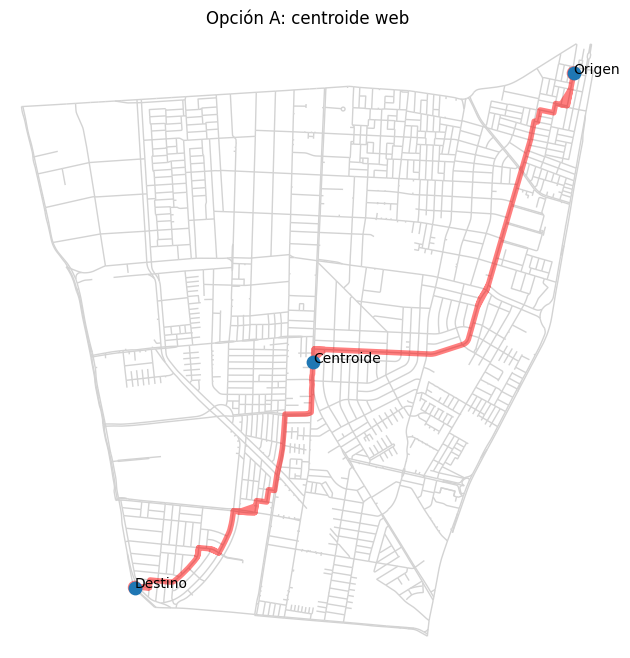


--- Opción B: distrito censal central ---
Largo origen -> centroide: 4470.99 m
Largo centroide -> destino: 2591.27 m
Largo total: 7062.26 m


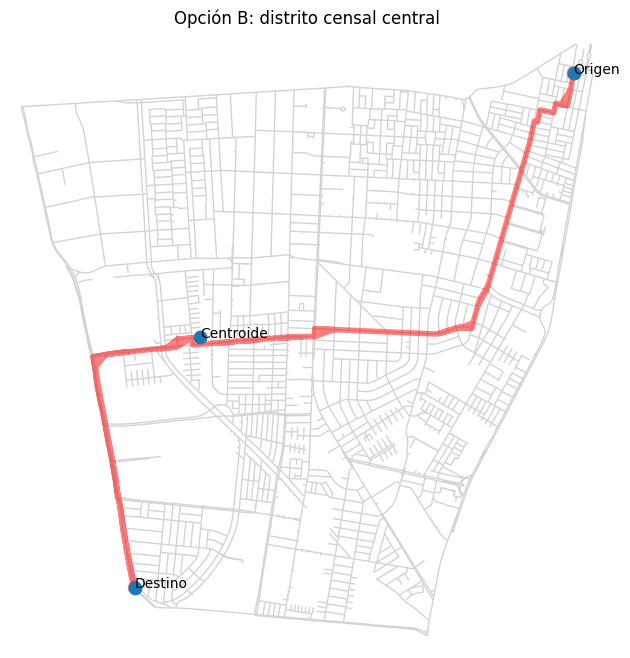


--- Opción C: centroide con dissolve ---
Largo origen -> centroide: 3518.78 m
Largo centroide -> destino: 2998.61 m
Largo total: 6517.39 m


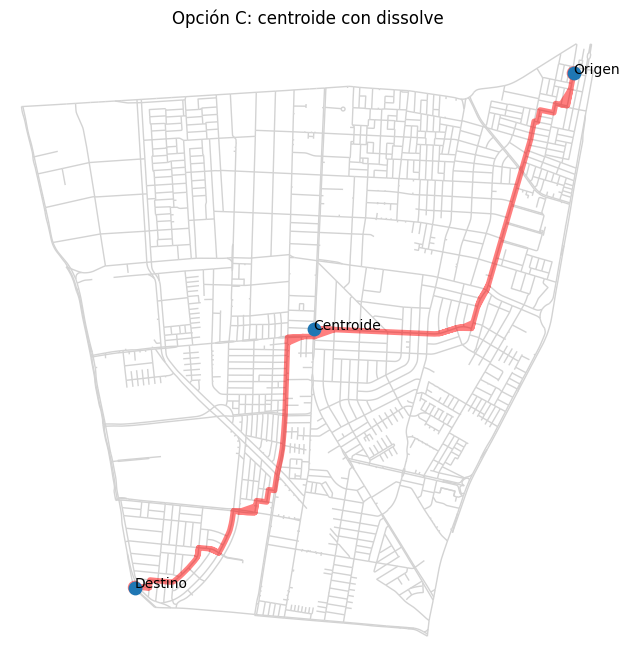

In [36]:
resultados = []
rutas = {}

for nombre, nodo_centroide in [
    ("Opción A: centroide web", nodo_opcion_a),
    ("Opción B: distrito censal central", nodo_centro_b),
    ("Opción C: centroide con dissolve", nodo_centro_c)
]:
    print(f"\n--- {nombre} ---")

    G_ruteo, ruta_final, largo_total, largo_1, largo_2 = ruta_pasando_por_centroide(
        G,
        nodo_origen=nodo_ne,
        nodo_destino=nodo_sw,
        nodo_centroide=nodo_centroide,
        usar_no_dirigido=True
    )

    print(f"Largo origen -> centroide: {largo_1:.2f} m")
    print(f"Largo centroide -> destino: {largo_2:.2f} m")
    print(f"Largo total: {largo_total:.2f} m")

    graficar_ruta_pasando_por_centroide(
        G_ruteo,
        ruta_final,
        nodo_origen=nodo_ne,
        nodo_centroide=nodo_centroide,
        nodo_destino=nodo_sw,
        titulo=nombre
    )

    rutas[nombre] = ruta_final

    resultados.append({
        "opcion": nombre,
        "largo_origen_centroide_m": largo_1,
        "largo_centroide_destino_m": largo_2,
        "largo_total_m": largo_total
    })

9. Compare esta ruta y su longitud con la ruta  ́optima que une ambos puntos extremos

In [37]:
G_ruteo = G.to_undirected()

ruta_optima = nx.shortest_path(
    G_ruteo,
    source=nodo_ne,
    target=nodo_sw,
    weight="length"
)

largo_optimo = nx.shortest_path_length(
    G_ruteo,
    source=nodo_ne,
    target=nodo_sw,
    weight="length"
)

print(f"Largo ruta óptima directa: {largo_optimo:.2f} m")

Largo ruta óptima directa: 6076.46 m


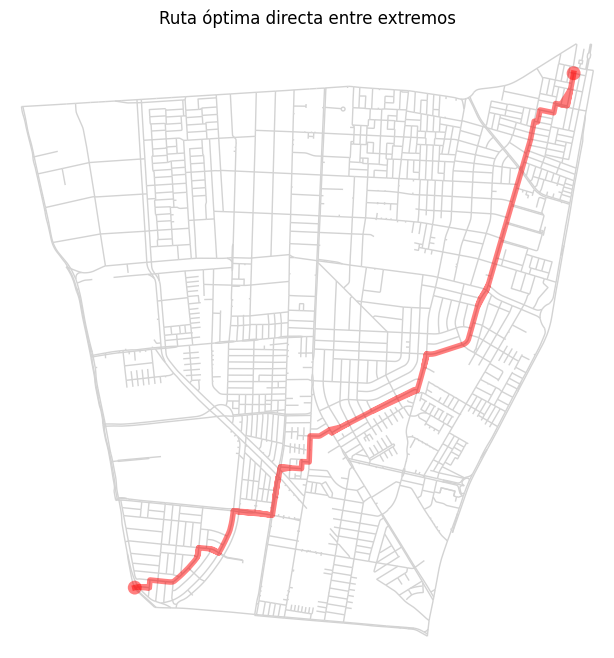

In [38]:
fig, ax = ox.plot_graph_route(
    G_ruteo,
    ruta_optima,
    route_linewidth=4,
    node_size=0,
    edge_color="lightgray",
    bgcolor="white",
    figsize=(8, 8),
    show=False,
    close=False
)

ax.set_title("Ruta óptima directa entre extremos")
plt.show()

In [39]:
df_resultados = pd.DataFrame(resultados)

df_resultados["largo_ruta_directa_m"] = largo_optimo
df_resultados["diferencia_vs_directa_m"] = (
    df_resultados["largo_total_m"] - df_resultados["largo_ruta_directa_m"]
)

df_resultados["aumento_porcentual"] = (
    df_resultados["diferencia_vs_directa_m"] / df_resultados["largo_ruta_directa_m"] * 100
)

df_resultados

,opcion,largo_origen_centroide_m,largo_centroide_destino_m,largo_total_m,largo_ruta_directa_m,diferencia_vs_directa_m,aumento_porcentual
0,Opción A: centroide web,3576.264698,2751.555251,6327.819949,6076.457527,251.362422,4.136661
1,Opción B: distrito censal central,4470.987691,2591.273734,7062.261425,6076.457527,985.803897,16.223332
2,Opción C: centroide con dissolve,3518.781827,2998.606992,6517.388820,6076.457527,440.931292,7.256387


La ruta directa entre los extremos de Macul corresponde al menor camino posible dentro de la red vial considerada. Por esto, las rutas que obligan a pasar por un punto intermedio asociado al centroide presentan una longitud mayor o igual.

Como extra, podemos ver:

In [40]:
from matplotlib.lines import Line2D

def graficar_todas_las_rutas(
    G_ruteo,
    ruta_directa,
    rutas_centroide,
    nodo_origen,
    nodo_destino,
    nodos_centroides,
    titulo="Comparación de rutas"
):
    ### rutas_centroide: dict {nombre_opcion: ruta}
    ### nodos_centroides: dict {nombre_opcion: nodo_centroide}

    nombres = list(rutas_centroide.keys())
    rutas = [ruta_directa] + [rutas_centroide[n] for n in nombres]
    colores = ["black", "red", "blue", "green"]
    anchos = [5, 4, 4, 4]

    fig, ax = ox.plot_graph_routes(
        G_ruteo,
        routes=rutas,
        route_colors=colores[:len(rutas)],
        route_linewidths=anchos[:len(rutas)],
        node_size=0,
        edge_color="lightgray",
        bgcolor="white",
        figsize=(10, 10),
        show=False,
        close=False
    )

    # origen y destino
    xs_extremos = [G_ruteo.nodes[nodo_origen]["x"], G_ruteo.nodes[nodo_destino]["x"]]
    ys_extremos = [G_ruteo.nodes[nodo_origen]["y"], G_ruteo.nodes[nodo_destino]["y"]]
    ax.scatter(xs_extremos, ys_extremos, s=90, c="black", zorder=5)

    ax.text(xs_extremos[0], ys_extremos[0], "Origen", fontsize=10, zorder=6)
    ax.text(xs_extremos[1], ys_extremos[1], "Destino", fontsize=10, zorder=6)

    # centroides
    colores_centroides = ["red", "blue", "green"]
    for i, nombre in enumerate(nombres):
        nodo_c = nodos_centroides[nombre]
        x = G_ruteo.nodes[nodo_c]["x"]
        y = G_ruteo.nodes[nodo_c]["y"]
        ax.scatter(x, y, s=80, c=colores_centroides[i], zorder=5)
        ax.text(x, y, f"C{i+1}", fontsize=10, zorder=6)

    handles = [
        Line2D([0], [0], color="black", lw=5, label="Ruta directa"),
        Line2D([0], [0], color="red", lw=4, label=nombres[0]),
        Line2D([0], [0], color="blue", lw=4, label=nombres[1]),
        Line2D([0], [0], color="green", lw=4, label=nombres[2]),
    ]

    ax.legend(handles=handles, loc="best")
    ax.set_title(titulo)
    plt.show()

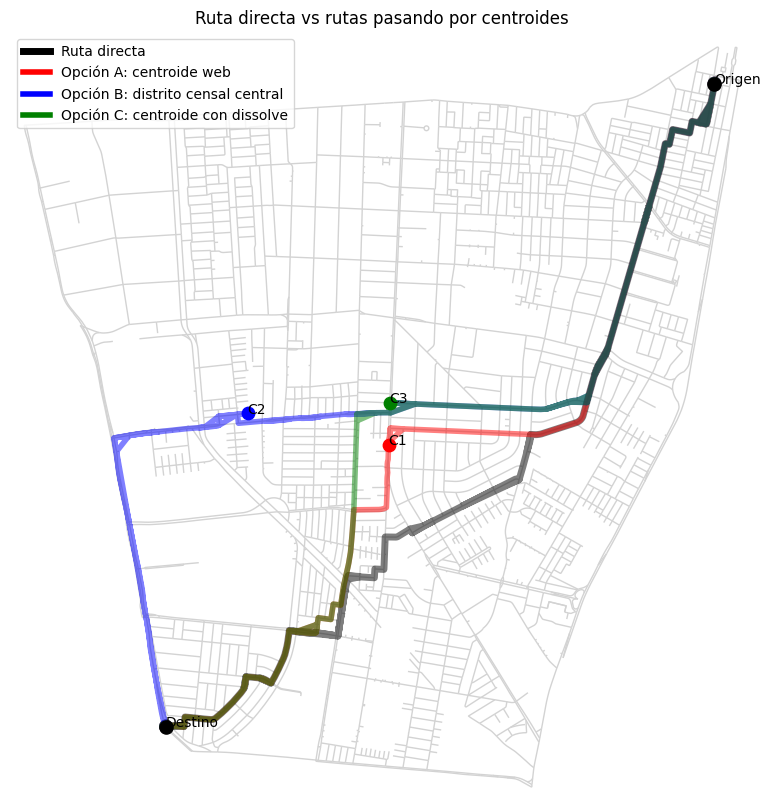

In [41]:
nodos_centroides = {
    "Opción A: centroide web": nodo_opcion_a,
    "Opción B: distrito censal central": nodo_centro_b,
    "Opción C: centroide con dissolve": nodo_centro_c
}

graficar_todas_las_rutas(
    G_ruteo,
    ruta_optima,
    rutas,
    nodo_ne,
    nodo_sw,
    nodos_centroides,
    titulo="Ruta directa vs rutas pasando por centroides"
)